In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


In [2]:
FolderName='/project/lhansen/Cap_NN_oldVersion/New_Econ_Parameters/output/Retrain_0.01_LR_piecewiseconstant_10e-6,10e-6,10e-6,10e-6_128_neurons_32_#HiddenLayer_4_logxi_-3.0_logximax_5.0_num_iterations1000000'

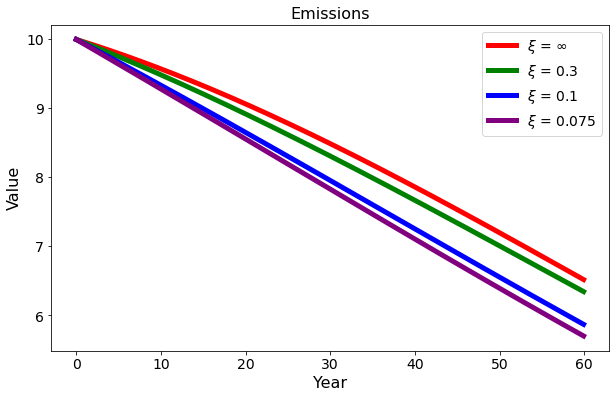

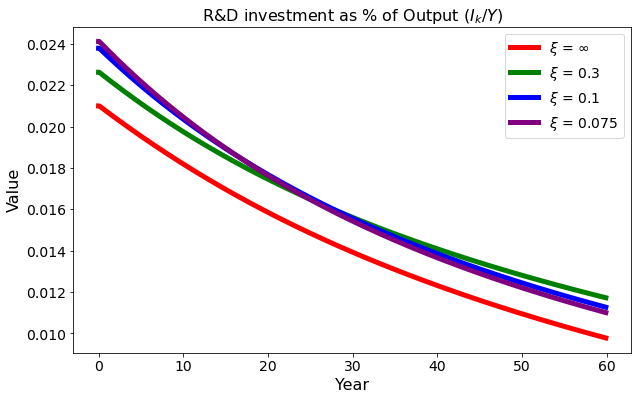

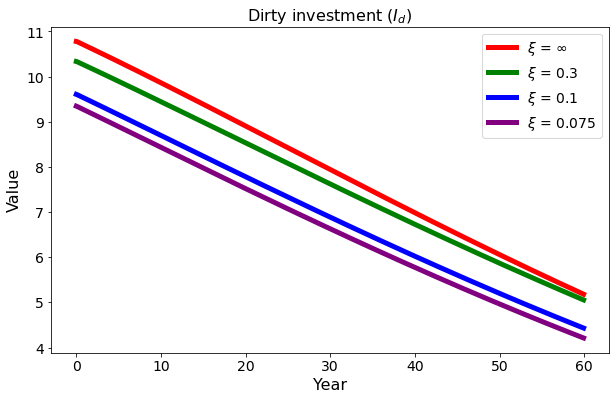

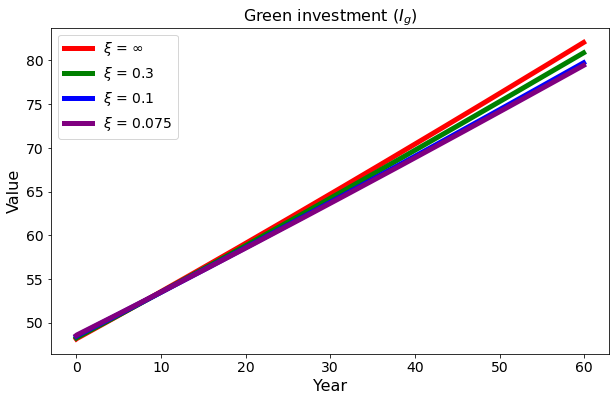

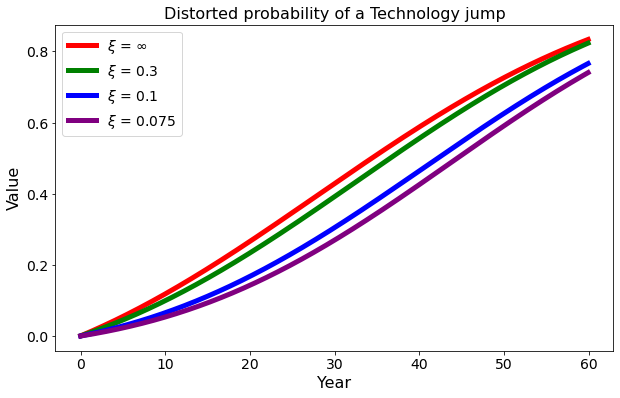

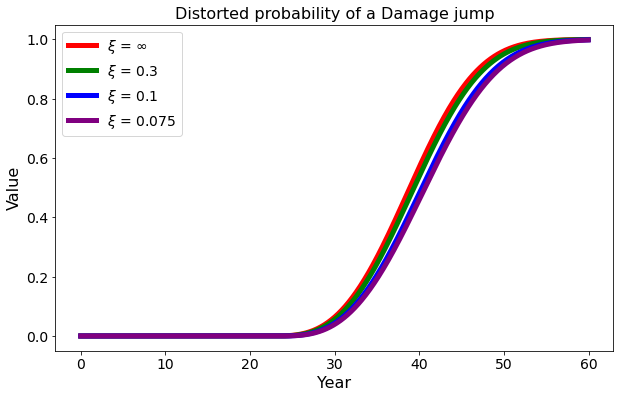

In [3]:
# Function to read values from a file
def read_values(file_path):
    values = []
    with open(file_path, 'r') as file:
        for line in file:
            values.append(float(line.strip()))
    return values

Name=["Emissions","RD","Id","Ig","TechJumpProb","DmgJumpProb"]
for txt_name in Name:
    # File paths 5, -1. -3
    # Cap_damage/TwoCapital_NN/output/A_g_prime_1_Delta_0.01_LR_piecewiseconstant_10e-5,10e-5,10e-5,10e-5_128_neurons_32_#HiddenLayer_4_logxi_-3.0_logximax_5.0_num_iterations600000
    file_path1 = FolderName+f'/final_output/pre_tech_pre_damage/log_xi_idx_3/{txt_name}.txt'
    file_path2 = FolderName+f'/final_output/pre_tech_pre_damage/log_xi_idx_2/{txt_name}.txt'
    file_path3 = FolderName+f'/final_output/pre_tech_pre_damage/log_xi_idx_1/{txt_name}.txt'
    file_path4 = FolderName+f'/final_output/pre_tech_pre_damage/log_xi_idx_0/{txt_name}.txt'
  
    # Read values from the files
    values1 = read_values(file_path1)
    values2 = read_values(file_path2)
    values3 = read_values(file_path3)
    values4 = read_values(file_path4)
    values1 = values1[:720]
    values2 = values2[:720]
    values3 = values3[:720]
    values4 = values4[:720]
    # Indices for the values
    indices1 = [x / 12 for x in range(len(values1))]
    indices2 = [x / 12 for x in range(len(values2))]
    indices3 = [x / 12 for x in range(len(values3))]
    indices4 = [x / 12 for x in range(len(values4))]

    # Plotting the values from both files
    plt.figure(figsize=(10, 6))

    plt.plot(indices1, values1,  color='r', label=r'$\xi$ = $\infty$',linewidth=5)
    plt.plot(indices2, values2,  color='g', label=r'$\xi$ = 0.3',linewidth=5)
    plt.plot(indices3, values3,  color='b', label=r'$\xi$ = 0.1',linewidth=5)
    plt.plot(indices4, values4,  color='purple', label=r'$\xi$ = 0.075',linewidth=5)
    
    if txt_name == "RD":
        plt.title(r'R&D investment as % of Output $(I_k/Y)$',fontsize=16)
    elif txt_name =="Id":
        plt.title(r'Dirty investment $(I_d)$',fontsize=16)
    elif txt_name =="Ig":
        plt.title(r'Green investment $(I_g)$',fontsize=16)
    elif txt_name =="TechJumpProb":
        plt.title('Distorted probability of a Technology jump',fontsize=16)
    elif txt_name =="DmgJumpProb":
        plt.title('Distorted probability of a Damage jump',fontsize=16)
    elif txt_name =="TechJumpIntensity":
        plt.title('Distorted Intensity of a Technology jump',fontsize=16)
    elif txt_name =="DmgJumpIntensity":
        plt.title('Distorted Intensity of a Damage jump',fontsize=16)    
        
    else:
        plt.title(f'{txt_name}',fontsize=16)
    plt.xlabel('Year',fontsize=16)
    plt.ylabel('Value',fontsize=16)
    plt.xticks(fontsize=14)  
    plt.yticks(fontsize=14)  
    plt.legend(fontsize=14)  
    plt.show()

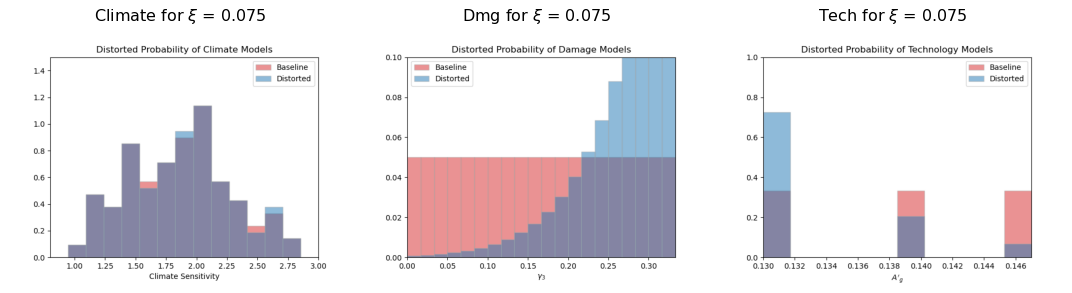

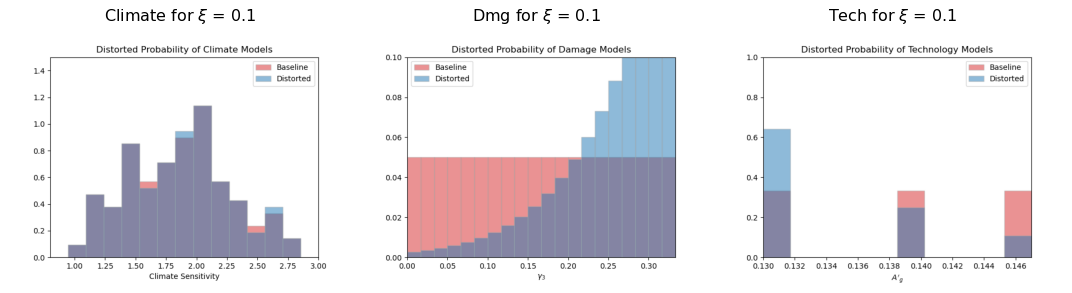

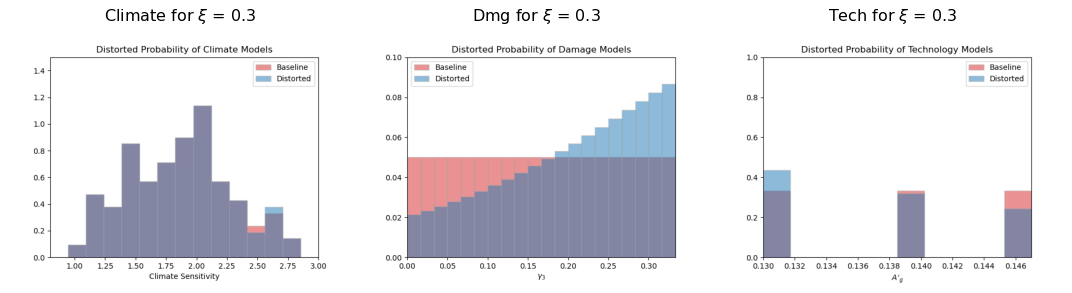

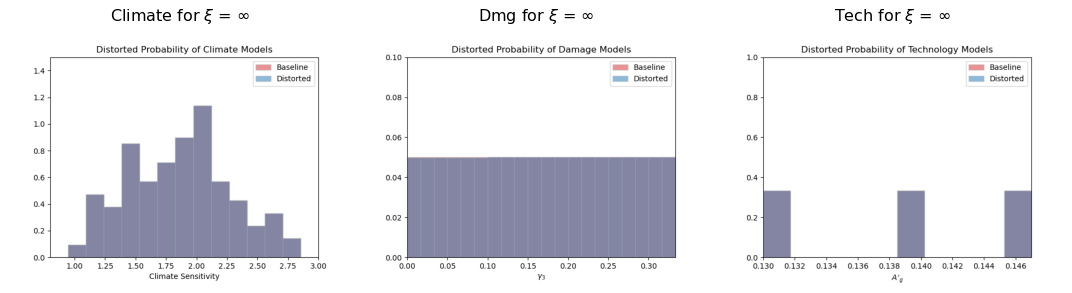

In [4]:
ImageTypes = ["Climate_Dist_IMSI_2023.png", "Dmg_Dist_IMSI_2023.png", "Tech_Dist_IMSI_2023.png"]


xi_label = [r'$\xi$ = 0.075',r'$\xi$ = 0.1', r'$\xi$ = 0.3',r'$\xi$ = $\infty$']

# Loop through each xi folder
for idx in range(4):
    plt.figure(figsize=(15, 5))  # Adjust size to better fit three images

    # Load and display each type of image
    for i, img_type in enumerate(ImageTypes):
        img_path = f'{FolderName}/final_output/pre_tech_pre_damage/log_xi_idx_{idx}/{img_type}'
        img = mpimg.imread(img_path)
        plt.subplot(1, 3, i + 1)  # One row, three columns, position i+1
        plt.imshow(img)
        plt.title(img_type.split("_")[0] + f' for {xi_label[idx]}', fontsize=16)
        plt.axis('off')  # Hide axis

    plt.tight_layout()
    plt.show()


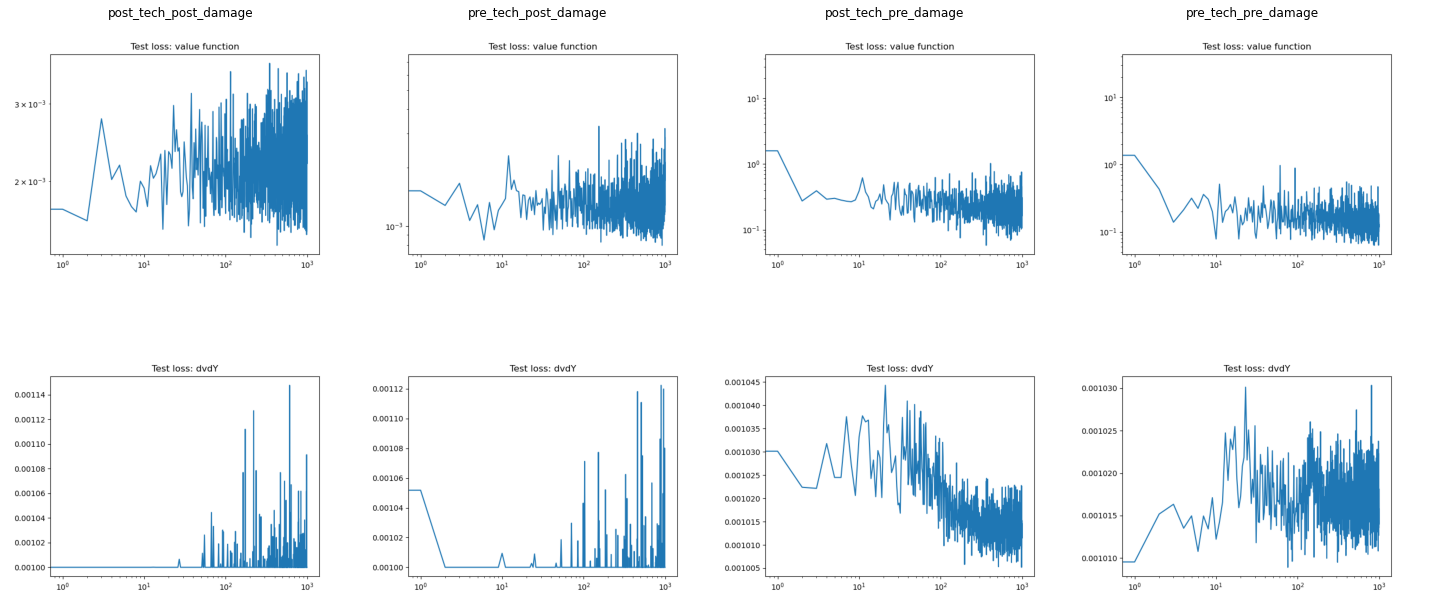

In [6]:
Foldername = "/project/lhansen/Cap_NN_oldVersion/New_Econ_Parameters/output/NewParameters_0.01_LR_piecewiseconstant_10e-5,10e-5,10e-5,10e-5_128_neurons_32_#HiddenLayer_4_logxi_-3.0_logximax_5.0_num_iterations2000000"
Foldername =FolderName
subfolders = [
    'post_tech_post_damage',
    'pre_tech_post_damage',
    'post_tech_pre_damage',
    'pre_tech_pre_damage'
]

# Create a figure with 2 rows (one per image type) and as many columns as subfolders
fig, axes = plt.subplots(2, len(subfolders), figsize=(20, 10))

# Loop over each subfolder to load and plot the images
for i, subfolder in enumerate(subfolders):
    # Build the full path for each image file
    loss_v_path = os.path.join(Foldername , subfolder, 'loss_v_history.png')
    loss_controls_path = os.path.join(Foldername , subfolder, 'loss_controls_dv_dY.png')
    
    # Load the images
    img_loss_v = mpimg.imread(loss_v_path)
    img_loss_controls = mpimg.imread(loss_controls_path)
    
    # Plot the loss_v_history image in the top row
    axes[0, i].imshow(img_loss_v)
    axes[0, i].axis('off')
    axes[0, i].set_title(subfolder, fontsize=12)
    
    # Plot the loss_controls_dv_dY image in the bottom row
    axes[1, i].imshow(img_loss_controls)
    axes[1, i].axis('off')
    # Optionally, you can repeat the title or leave it off in the second row.
    # axes[1, i].set_title(subfolder, fontsize=12)

# Optionally, add labels to the rows to indicate which image is which
axes[0, 0].set_ylabel('loss_v_history', fontsize=14)
axes[1, 0].set_ylabel('loss_controls_dv_dY', fontsize=14)

plt.tight_layout()
plt.show()